# 관광 챗봇 이벤트 로그 분석

`/tourism/chat` 응답 이벤트 로그(`data/generated/tour_api/query_card_events.jsonl`)를 확인하는 노트북이다.

- 기본 로그는 원문 질문을 저장하지 않고 `message_hash`만 저장한다.
- `lookup_mode`, `live_api_called`, 지역, 조건, 카드 노출 순위를 확인한다.
- 그래프는 `matplotlib`를 사용하며, macOS `AppleGothic` 또는 설치된 한글 폰트를 자동 선택한다.


## 1. 로그 로드

서버에서 `/tourism/chat`을 한 번 이상 호출한 뒤 실행한다. 로그 파일이 없으면 빈 결과로 처리한다.

In [1]:
from __future__ import annotations

from collections import Counter
from pathlib import Path
import json

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

LOG_PATH = PROJECT_ROOT / "data" / "generated" / "tour_api" / "query_card_events.jsonl"
print(f"프로젝트 루트: {PROJECT_ROOT}")
print(f"로그 파일: {LOG_PATH}")

events = []
if LOG_PATH.exists():
    for line in LOG_PATH.read_text(encoding="utf-8").splitlines():
        if line.strip():
            events.append(json.loads(line))

print(f"로드한 이벤트 수: {len(events)}")
if events:
    events[-1]


프로젝트 루트: /Users/cheng80/Desktop/chatbot_rag
로그 파일: /Users/cheng80/Desktop/chatbot_rag/data/generated/tour_api/query_card_events.jsonl
로드한 이벤트 수: 3


## 2. 한글 폰트 설정

macOS는 보통 `AppleGothic`이 잡힌다. 폰트가 없으면 설치된 한글 폰트를 순서대로 찾는다.

In [2]:
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams

def configure_korean_font() -> str | None:
    preferred = [
        "AppleGothic",
        "NanumGothic",
        "Noto Sans CJK KR",
        "Noto Sans KR",
        "Malgun Gothic",
    ]
    available = {}
    for font_path in font_manager.findSystemFonts():
        try:
            name = font_manager.FontProperties(fname=font_path).get_name()
            available[name] = font_path
        except Exception:
            continue

    for name in preferred:
        if name in available:
            rcParams["font.family"] = name
            rcParams["axes.unicode_minus"] = False
            return name

    rcParams["axes.unicode_minus"] = False
    return None

font_name = configure_korean_font()
print(f"사용 한글 폰트: {font_name or '자동 탐색 실패 - 시스템 기본 폰트 사용'}")


Fontconfig warning: ignoring C.UTF-8: not a valid language tag


사용 한글 폰트: AppleGothic


## 3. 요약 지표

`lookup_mode`와 실제 live API 호출 여부를 먼저 본다.

In [3]:
def count_values(key: str) -> Counter:
    return Counter(event.get(key) for event in events)

lookup_counts = count_values("lookup_mode")
live_call_counts = count_values("live_api_called")
degraded_counts = count_values("degraded")

summary = {
    "총 이벤트": len(events),
    "lookup_mode": dict(lookup_counts),
    "live_api_called": dict(live_call_counts),
    "degraded": dict(degraded_counts),
}
summary


{'총 이벤트': 3,
 'lookup_mode': {'indexed': 2, 'cache': 1},
 'live_api_called': {False: 3},
 'degraded': {False: 3}}

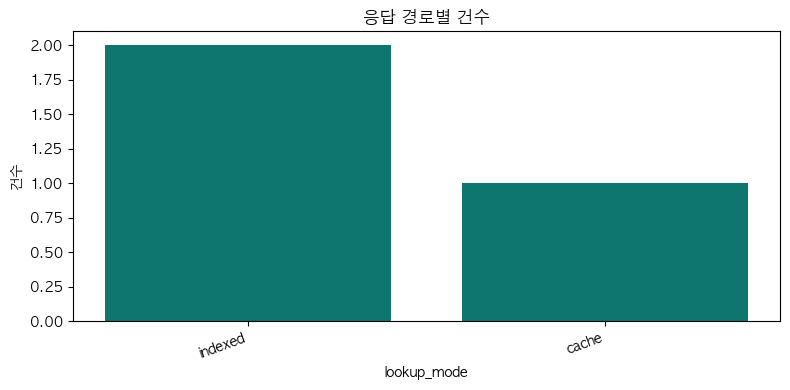

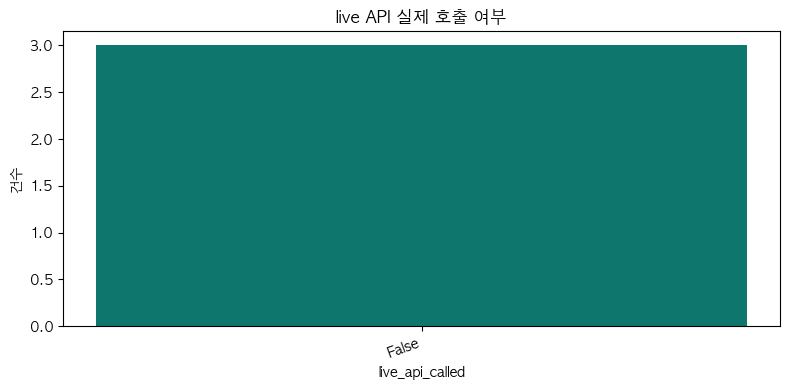

In [4]:
def plot_bar(counter: Counter, title: str, xlabel: str, ylabel: str = "건수") -> None:
    if not counter:
        print(f"{title}: 표시할 데이터가 없습니다.")
        return
    labels, values = zip(*counter.most_common())
    plt.figure(figsize=(8, 4))
    plt.bar([str(label) for label in labels], values, color="#0f766e")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

plot_bar(lookup_counts, "응답 경로별 건수", "lookup_mode")
plot_bar(live_call_counts, "live API 실제 호출 여부", "live_api_called")


## 4. 지역/조건 분석

어떤 지역과 조건이 많이 들어오는지 본다.

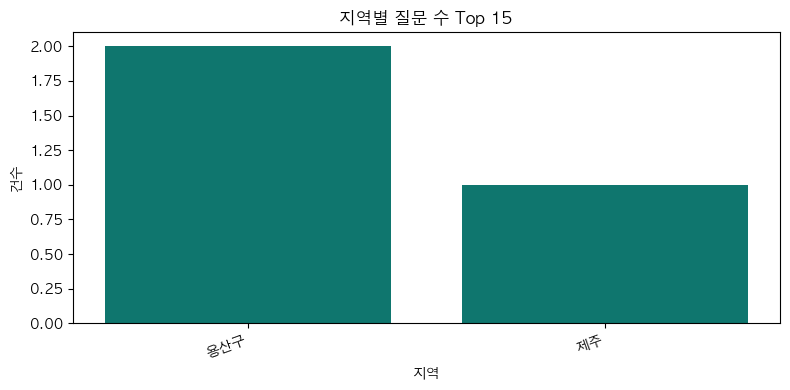

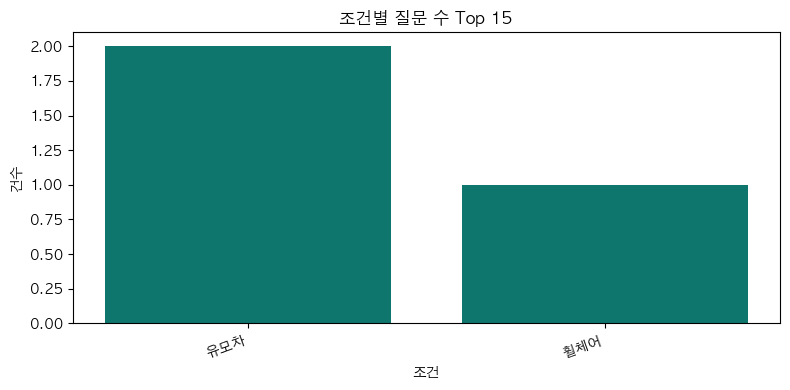

In [5]:
region_counts = Counter(event.get("region") or event.get("area_name") or "지역 없음" for event in events)
condition_counts = Counter()
for event in events:
    conditions = event.get("conditions") or ["조건 없음"]
    for condition in conditions:
        condition_counts[condition] += 1

plot_bar(Counter(dict(region_counts.most_common(15))), "지역별 질문 수 Top 15", "지역")
plot_bar(Counter(dict(condition_counts.most_common(15))), "조건별 질문 수 Top 15", "조건")


## 5. 카드 노출 분석

같은 카드가 얼마나 자주 추천되는지, 어떤 응답 경로에서 나왔는지 본다.

In [6]:
card_rows = []
for event in events:
    for card in event.get("cards") or []:
        card_rows.append(
            {
                "timestamp": event.get("timestamp"),
                "lookup_mode": event.get("lookup_mode"),
                "region": event.get("region"),
                "rank": card.get("rank"),
                "content_id": card.get("content_id"),
                "title": card.get("title"),
                "source_name": card.get("source_name"),
            }
        )

card_title_counts = Counter(row["title"] for row in card_rows if row.get("title"))
card_id_counts = Counter(row["content_id"] for row in card_rows if row.get("content_id"))

print(f"총 카드 노출 수: {len(card_rows)}")
print("자주 노출된 카드 Top 20")
for title, count in card_title_counts.most_common(20):
    print(f"{count:>3}  {title}")


총 카드 노출 수: 7
자주 노출된 카드 Top 20
  2  국립중앙박물관
  1  관덕정(제주)
  1  광양해장국집
  1  교래손칼국수(원조교래손칼국수)
  1  귤품은흑돼지 제주공항점
  1  곽지해수욕장


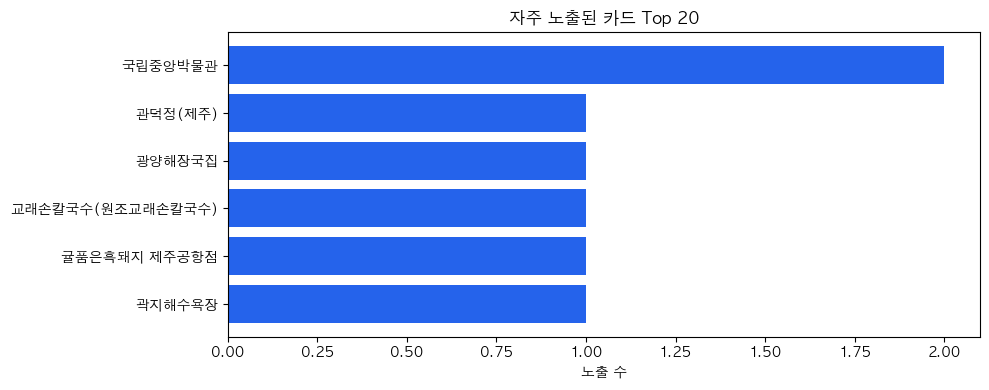

In [7]:
if card_title_counts:
    items = card_title_counts.most_common(20)
    labels = [title for title, _ in items][::-1]
    values = [count for _, count in items][::-1]
    plt.figure(figsize=(10, max(4, len(labels) * 0.35)))
    plt.barh(labels, values, color="#2563eb")
    plt.title("자주 노출된 카드 Top 20")
    plt.xlabel("노출 수")
    plt.tight_layout()
    plt.show()
else:
    print("카드 노출 데이터가 없습니다.")


## 6. 문제 후보 확인

no-results, degraded, warning이 있는 이벤트를 사람이 검토한다.

In [8]:
problem_events = []
for event in events:
    if event.get("lookup_mode") == "unknown" or event.get("degraded") or event.get("warnings"):
        problem_events.append(event)

print(f"검토 후보 이벤트 수: {len(problem_events)}")
for event in problem_events[:20]:
    print("-", {
        "timestamp": event.get("timestamp"),
        "lookup_mode": event.get("lookup_mode"),
        "region": event.get("region"),
        "conditions": event.get("conditions"),
        "live_api_called": event.get("live_api_called"),
        "warnings": event.get("warnings"),
        "message_hash": event.get("message_hash"),
    })


검토 후보 이벤트 수: 0


## 7. 다음 판단 기준

- `live_api_called=True`가 너무 많으면 fallback 보강이나 캐시 갱신 전략을 검토한다.
- `lookup_mode=unknown`이 많으면 지역 파싱, fallback 데이터, live 조회 조건을 점검한다.
- 특정 카드가 과도하게 반복 노출되면 음식점/비관광 후보 여부를 확인한다.
- JSONL 분석이 불편해질 만큼 이벤트가 늘어나면 Post-MVP에서 SQLite로 흡수한다.
